STEP 1 — Caricamento tabelle (comune a entrambe le coorti)
  patient: 2,520 righe OK
  treatment: 38,290 righe OK
  apacheApsVar: 2,205 righe OK
  apachePredVar: 2,205 righe OK
  apachePatientResult: 3,676 righe OK
  admissionDx: 7,578 righe OK
  pastHistory: 12,109 righe OK
  lab: 434,660 righe OK
  vitalPeriodic: 1,634,960 righe OK
  hospital: 186 righe OK

STEP 2 — Selezione coorte base (comune)
  Dataset totale            2,520
  Primo ICU stay            2,119
  Eta >= 18                 2,111
  Durata ICU >= 4h          2,019
  Y definibile              1,994
  No abx pre-ICU            1,980

  Coorte base (pre-A): 1,980 pazienti

STEP 3 — Estrazione covariate X (comune)
  Feature disponibili: 31
  Missing residui:     0

FINESTRA 24h — Definizione A (trattamento entro 24h)
  N totale:  1,980
  A=1:       394 (19.9%)  mortalita: 10.9%
  A=0:       1,586 (80.1%)  mortalita: 7.4%
  Y=1:       160 (8.1%)
  Differenza grezza: +3.5%
  Salvato:   ../data/processed/dataset_XAY_24h.csv


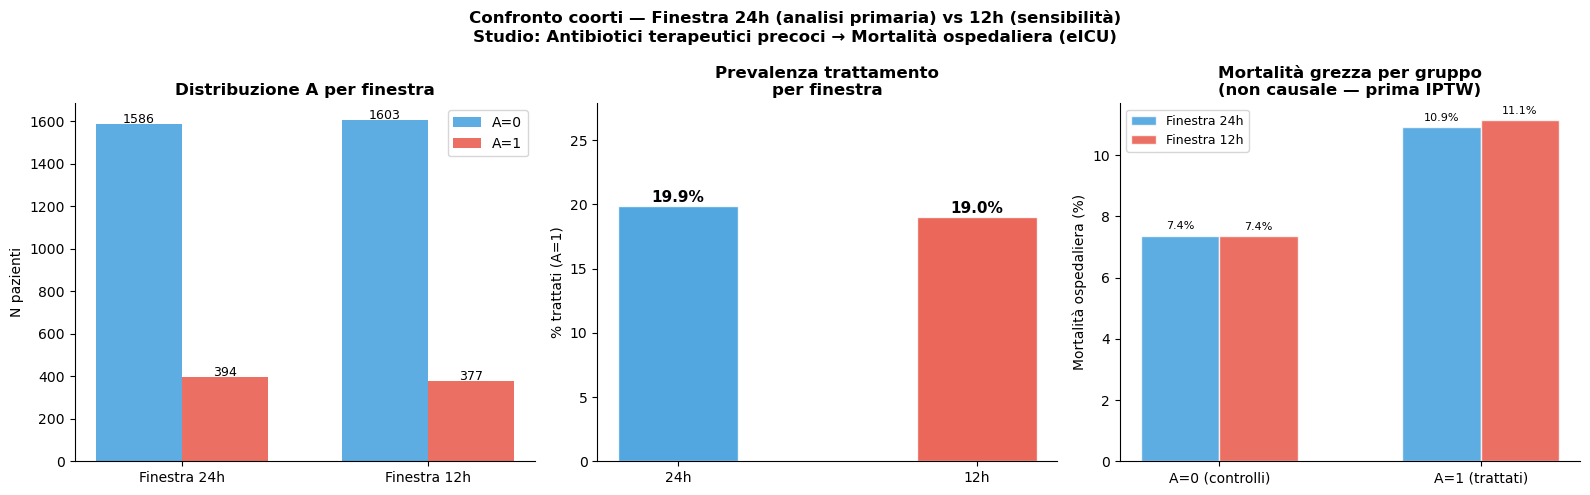

  Figura salvata: ../output_png/sensitivity_24h_vs_12h.png

RIEPILOGO FINALE
                                        24h         12h
  ────────────────────────────────────────────────────
  N totale                            1,980       1,980
  A=1 (trattati)                        394         377
  % trattati                          19.9%       19.0%
  Mortalità A=1                       10.9%       11.1%
  Mortalità A=0                        7.4%        7.4%
  Diff. grezza (naive ATE)            +3.5%       +3.8%

  File salvati:
    ../data/processed/dataset_XAY_24h.csv  ← analisi primaria
    ../data/processed/dataset_XAY_12h.csv  ← analisi di sensibilità


In [25]:
"""
Costruzione Dataset Analitico (X=31, A, Y) — eICU demo
Studio: Antibiotici terapeutici precoci -> Mortalita ospedaliera
Framework: Target Trial Emulation (Hernan 2022)

Genera DUE dataset:
  - dataset_XAY_24h.csv  (finestra trattamento 24h — analisi primaria)
  - dataset_XAY_12h.csv  (finestra trattamento 12h — analisi di sensibilità)
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

UP      = "../data/raw/"
OUT_PNG = "../output_png/"

VITAL_WIN = 120
LAB_WIN   = 360

# ── Finestre da costruire ─────────────────────────────────────
WINDOWS = {
    "24h": 24 * 60,
    "12h": 12 * 60,
}

# ─────────────────────────────────────────
# UTILITY
# ─────────────────────────────────────────
def load(name, usecols=None):
    try:
        df = pd.read_csv(f"{UP}{name}.csv", usecols=usecols)
        print(f"  {name}: {len(df):,} righe OK")
        return df
    except FileNotFoundError:
        print(f"  {name}: NON TROVATA")
        return None

# ─────────────────────────────────────────
# STEP 1 — CARICA TABELLE (una sola volta)
# ─────────────────────────────────────────
print("=" * 60)
print("STEP 1 — Caricamento tabelle (comune a entrambe le coorti)")
print("=" * 60)

patient    = load("patient",    ["patientunitstayid","gender","age","hospitalid",
                                  "hospitaldischargestatus","unitdischargestatus",
                                  "unitdischargeoffset","unitvisitnumber",
                                  "admissionweight","admissionheight","hospitaladmitsource"])
treatment  = load("treatment",  ["patientunitstayid","treatmentoffset","treatmentstring"])
apache_aps = load("apacheApsVar", ["patientunitstayid","eyes","motor","verbal",
                                   "heartrate","meanbp","respiratoryrate","temperature",
                                   "ph","pao2","fio2","creatinine","wbc","glucose"])
apache_pred= load("apachePredVar",["patientunitstayid","diabetes","aids","hepaticfailure",
                                   "metastaticcancer","immunosuppression","cirrhosis","electivesurgery"])
apache_res = load("apachePatientResult",["patientunitstayid","apachescore",
                                         "acutephysiologyscore","predictedhospitalmortality"])
adm_dx     = load("admissionDx",  ["patientunitstayid","admitdxpath"])
past_hist  = load("pastHistory",  ["patientunitstayid","pasthistorypath"])
lab        = load("lab",          ["patientunitstayid","labresultoffset","labname","labresult"])
vital      = load("vitalPeriodic",["patientunitstayid","observationoffset","sao2",
                                   "heartrate","respiration","systemicmean","temperature"])
hospital   = load("hospital",     ["hospitalid","numbedscategory","teachingstatus","region"])


# ─────────────────────────────────────────
# STEP 2 — COORTE BASE (comune a entrambe)
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 2 — Selezione coorte base (comune)")
print("=" * 60)

flow_base = []
N0        = len(patient)
flow_base.append(("Dataset totale", N0))

cohort_base = patient[patient["unitvisitnumber"] == 1].copy()
flow_base.append(("Primo ICU stay", len(cohort_base)))

cohort_base["age_num"] = cohort_base["age"].replace("> 89", "90")
cohort_base["age_num"] = pd.to_numeric(cohort_base["age_num"], errors="coerce")
cohort_base = cohort_base[cohort_base["age_num"] >= 18]
flow_base.append(("Eta >= 18", len(cohort_base)))

cohort_base = cohort_base[cohort_base["unitdischargeoffset"] >= 240]
flow_base.append(("Durata ICU >= 4h", len(cohort_base)))

cohort_base = cohort_base[cohort_base["hospitaldischargestatus"].isin(["Alive","Expired"])]
flow_base.append(("Y definibile", len(cohort_base)))

try:
    eol = pd.read_csv(f"{UP}carePlanEOL_csv.gz", usecols=["patientunitstayid"])
    cohort_base = cohort_base[~cohort_base["patientunitstayid"].isin(set(eol["patientunitstayid"]))]
    flow_base.append(("No comfort care", len(cohort_base)))
except:
    pass

# Y — uguale per entrambe le finestre
cohort_base["Y"] = (cohort_base["hospitaldischargestatus"] == "Expired").astype(int)

# Antibiotici pre-ICU — da escludere in entrambe
def is_therapeutic(s):
    s = str(s).lower()
    if "prophylactic" in s: return False
    return any(k in s for k in ["therapeutic antibacterials",
        "pulmonary|medications|antibacterials",
        "cardiovascular|other therapies|antibacterials"])

ids_base = set(cohort_base["patientunitstayid"])
tc       = treatment[treatment["patientunitstayid"].isin(ids_base)].copy()
abx      = tc[tc["treatmentstring"].apply(is_therapeutic)]
fa       = (abx.sort_values("treatmentoffset")
              .groupby("patientunitstayid").first().reset_index()
              [["patientunitstayid","treatmentoffset"]])
fa.columns = ["patientunitstayid","abx_offset"]

pre_icu     = set(fa[fa["abx_offset"] < 0]["patientunitstayid"])
cohort_base = cohort_base[~cohort_base["patientunitstayid"].isin(pre_icu)]
flow_base.append(("No abx pre-ICU", len(cohort_base)))

ids_base = set(cohort_base["patientunitstayid"])
fa_valid = fa[fa["patientunitstayid"].isin(ids_base) & (fa["abx_offset"] >= 0)]

for label, n in flow_base:
    print(f"  {label:<25} {n:,}")
print(f"\n  Coorte base (pre-A): {len(cohort_base):,} pazienti")


# ─────────────────────────────────────────
# STEP 3 — ESTRAI COVARIATE X (una sola volta)
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 3 — Estrazione covariate X (comune)")
print("=" * 60)

df_x = cohort_base[["patientunitstayid","Y","age_num",
                     "admissionweight","admissionheight",
                     "gender","hospitalid"]].copy()

if apache_res is not None:
    ares = (apache_res[apache_res["patientunitstayid"].isin(ids_base)]
            .groupby("patientunitstayid").first().reset_index()
            [["patientunitstayid","apachescore","acutephysiologyscore",
              "predictedhospitalmortality"]])
    df_x = df_x.merge(ares, on="patientunitstayid", how="left")

if apache_aps is not None:
    aps = (apache_aps[apache_aps["patientunitstayid"].isin(ids_base)]
           .groupby("patientunitstayid").first().reset_index())
    keep = ["patientunitstayid","eyes","motor","verbal",
            "heartrate","meanbp","respiratoryrate","temperature",
            "ph","pao2","fio2","creatinine","wbc","glucose"]
    aps  = aps[[c for c in keep if c in aps.columns]].copy()
    aps.columns = ["patientunitstayid"] + [f"aps_{c}" for c in aps.columns[1:]]
    df_x = df_x.merge(aps, on="patientunitstayid", how="left")

if vital is not None:
    vit = vital[vital["patientunitstayid"].isin(ids_base) &
                (vital["observationoffset"] >= 0) &
                (vital["observationoffset"] <= VITAL_WIN)].copy()
    vit_agg = vit.groupby("patientunitstayid").agg(
        vital_sao2_min =("sao2",        "min"),
        vital_hr_mean  =("heartrate",   "mean"),
        vital_map_mean =("systemicmean","mean"),
        vital_rr_mean  =("respiration", "mean"),
        vital_temp_mean=("temperature", "mean"),
    ).reset_index()
    df_x = df_x.merge(vit_agg, on="patientunitstayid", how="left")

if lab is not None:
    lab_c = lab[lab["patientunitstayid"].isin(ids_base) &
                (lab["labresultoffset"] >= 0) &
                (lab["labresultoffset"] <= LAB_WIN)].copy()
    LAB_MAP = {"lactate":"lab_lactate","WBC x 1000":"lab_wbc",
               "creatinine":"lab_creatinine","bicarbonate":"lab_bicarbonate",
               "glucose":"lab_glucose","Hgb":"lab_hgb",
               "platelets x 1000":"lab_platelets","BUN":"lab_bun"}
    for lname, lcol in LAB_MAP.items():
        sub = (lab_c[lab_c["labname"]==lname].sort_values("labresultoffset")
               .groupby("patientunitstayid")["labresult"].first()
               .reset_index().rename(columns={"labresult":lcol}))
        df_x = df_x.merge(sub, on="patientunitstayid", how="left")

if adm_dx is not None:
    adx = adm_dx[adm_dx["patientunitstayid"].isin(ids_base)].copy()
    adx["infective_dx"] = adx["admitdxpath"].str.lower().str.contains(
        "sepsis|infect|pneumon|bacteremia|respiratory", na=False).astype(int)
    adx["cardiac_dx"]   = adx["admitdxpath"].str.lower().str.contains(
        "cardiovascular|cardiac|arrhythmia|heart", na=False).astype(int)
    adx["neuro_dx"]     = adx["admitdxpath"].str.lower().str.contains(
        "neurolog|coma|seizure|stroke", na=False).astype(int)
    adx_agg = adx.groupby("patientunitstayid").agg(
        infective_dx=("infective_dx","max"),
        cardiac_dx  =("cardiac_dx",  "max"),
        neuro_dx    =("neuro_dx",    "max")).reset_index()
    df_x = df_x.merge(adx_agg, on="patientunitstayid", how="left")

if apache_pred is not None:
    apred = (apache_pred[apache_pred["patientunitstayid"].isin(ids_base)]
             .groupby("patientunitstayid").first().reset_index()
             [["patientunitstayid","diabetes","aids","hepaticfailure",
               "metastaticcancer","immunosuppression","cirrhosis","electivesurgery"]])
    df_x = df_x.merge(apred, on="patientunitstayid", how="left")

if past_hist is not None:
    ph = past_hist[past_hist["patientunitstayid"].isin(ids_base)].copy()
    ph["hx_htn"]  = ph["pasthistorypath"].str.lower().str.contains("hypertension",     na=False).astype(int)
    ph["hx_chf"]  = ph["pasthistorypath"].str.lower().str.contains("heart failure|chf",na=False).astype(int)
    ph["hx_copd"] = ph["pasthistorypath"].str.lower().str.contains("copd",             na=False).astype(int)
    ph["hx_ckd"]  = ph["pasthistorypath"].str.lower().str.contains("renal|kidney",     na=False).astype(int)
    ph_agg = ph.groupby("patientunitstayid").agg(
        hx_htn=("hx_htn","max"), hx_chf=("hx_chf","max"),
        hx_copd=("hx_copd","max"), hx_ckd=("hx_ckd","max")).reset_index()
    df_x = df_x.merge(ph_agg, on="patientunitstayid", how="left")

if hospital is not None:
    df_x = df_x.merge(hospital, on="hospitalid", how="left")

df_x["gender_male"] = (df_x["gender"] == "Male").astype(int)
df_x = df_x.drop(columns=["gender","hospitalid","teachingstatus",
                            "numbedscategory","region"], errors="ignore")

FEATURES_31 = [f for f in [
    "age_num","gender_male","admissionweight","admissionheight",
    "predictedhospitalmortality",
    "aps_eyes","aps_motor","aps_verbal",
    "aps_heartrate","aps_meanbp","aps_respiratoryrate","aps_temperature",
    "aps_ph","aps_pao2","aps_creatinine","aps_wbc","aps_glucose",
    "vital_sao2_min",
    "infective_dx","cardiac_dx","neuro_dx",
    "diabetes","cirrhosis","hepaticfailure",
    "immunosuppression","metastaticcancer","aids",
    "hx_htn","hx_chf","hx_copd","hx_ckd",
] if f in df_x.columns]

BINARY = ["gender_male","infective_dx","cardiac_dx","neuro_dx",
          "diabetes","cirrhosis","hepaticfailure",
          "immunosuppression","metastaticcancer","aids",
          "hx_htn","hx_chf","hx_copd","hx_ckd"]
NUM    = [f for f in FEATURES_31 if f not in BINARY]

df_x_imp = df_x.copy()
for col in NUM:
    if col in df_x_imp.columns and df_x_imp[col].isnull().any():
        df_x_imp[col] = df_x_imp[col].fillna(df_x_imp[col].median())
for col in BINARY:
    if col in df_x_imp.columns:
        df_x_imp[col] = df_x_imp[col].fillna(0).astype(int)

print(f"  Feature disponibili: {len(FEATURES_31)}")
print(f"  Missing residui:     {df_x_imp[FEATURES_31].isnull().sum().sum()}")


# ═════════════════════════════════════════
# STEP 4 — LOOP SULLE DUE FINESTRE
# ═════════════════════════════════════════
results = {}

for win_label, TREAT_WIN in WINDOWS.items():

    print("\n" + "=" * 60)
    print(f"FINESTRA {win_label} — Definizione A (trattamento entro {win_label})")
    print("=" * 60)

    cohort_win = cohort_base.copy()
    cohort_win = cohort_win.merge(fa_valid, on="patientunitstayid", how="left")
    cohort_win["A"] = (
        cohort_win["abx_offset"].notna() &
        (cohort_win["abx_offset"] <= TREAT_WIN)
    ).astype(int)

    # Merge con covariate X già estratte e imputate
    df_final = df_x_imp.merge(
        cohort_win[["patientunitstayid","A"]],
        on="patientunitstayid", how="inner"
    )

    final_cols = ["patientunitstayid","Y","A"] + FEATURES_31
    df_final   = df_final[[c for c in final_cols if c in df_final.columns]]

    # Salvataggio
    out_path = f"../data/processed/dataset_XAY_{win_label}.csv"
    df_final.to_csv(out_path, index=False)

    m1 = df_final[df_final["A"]==1]["Y"].mean()*100
    m0 = df_final[df_final["A"]==0]["Y"].mean()*100

    print(f"  N totale:  {len(df_final):,}")
    print(f"  A=1:       {df_final['A'].sum():,} ({df_final['A'].mean()*100:.1f}%)  mortalita: {m1:.1f}%")
    print(f"  A=0:       {(df_final['A']==0).sum():,} ({(df_final['A']==0).mean()*100:.1f}%)  mortalita: {m0:.1f}%")
    print(f"  Y=1:       {df_final['Y'].sum():,} ({df_final['Y'].mean()*100:.1f}%)")
    print(f"  Differenza grezza: {m1-m0:+.1f}%")
    print(f"  Salvato:   {out_path}")

    results[win_label] = {
        "df":    df_final,
        "n":     len(df_final),
        "n_A1":  int(df_final["A"].sum()),
        "n_A0":  int((df_final["A"]==0).sum()),
        "pct_A1":df_final["A"].mean()*100,
        "m1":    m1,
        "m0":    m0,
        "naive": m1 - m0,
    }


# ═════════════════════════════════════════
# STEP 5 — FIGURA COMPARATIVA
# ═════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 5 — Figura comparativa 24h vs 12h")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Confronto coorti — Finestra 24h (analisi primaria) vs 12h (sensibilità)\n"
    "Studio: Antibiotici terapeutici precoci → Mortalità ospedaliera (eICU)",
    fontsize=12, fontweight="bold"
)

colors = {"24h": "#3498db", "12h": "#e74c3c"}

# ── Panel 1: N trattati per finestra ──────────────────────────
ax = axes[0]
labels = list(WINDOWS.keys())
n_A1   = [results[w]["n_A1"]  for w in labels]
n_A0   = [results[w]["n_A0"]  for w in labels]

x     = np.arange(len(labels))
width = 0.35
b1 = ax.bar(x - width/2, n_A0, width, label="A=0", color="#3498db", alpha=0.8)
b2 = ax.bar(x + width/2, n_A1, width, label="A=1", color="#e74c3c", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"Finestra {w}" for w in labels])
ax.set_ylabel("N pazienti")
ax.set_title("Distribuzione A per finestra", fontweight="bold")
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{int(bar.get_height())}", ha="center", fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── Panel 2: % trattati ───────────────────────────────────────
ax2 = axes[1]
pct_A1 = [results[w]["pct_A1"] for w in labels]
bars2  = ax2.bar(labels, pct_A1,
                 color=[colors[w] for w in labels],
                 alpha=0.85, edgecolor="white", width=0.4)
ax2.set_ylabel("% trattati (A=1)")
ax2.set_title("Prevalenza trattamento\nper finestra", fontweight="bold")
ax2.set_ylim(0, max(pct_A1) * 1.4)
for bar, v in zip(bars2, pct_A1):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f"{v:.1f}%", ha="center", fontsize=11, fontweight="bold")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# ── Panel 3: Mortalità grezza per gruppo e finestra ───────────
ax3 = axes[2]
x    = np.arange(2)
w_   = 0.3
for i, (win_label, res) in enumerate(results.items()):
    offset = (i - 0.5) * w_
    bars3  = ax3.bar(x + offset, [res["m0"], res["m1"]],
                     w_, label=f"Finestra {win_label}",
                     color=colors[win_label], alpha=0.8, edgecolor="white")
    for bar, v in zip(bars3, [res["m0"], res["m1"]]):
        ax3.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f"{v:.1f}%", ha="center", fontsize=8)

ax3.set_xticks(x)
ax3.set_xticklabels(["A=0 (controlli)", "A=1 (trattati)"])
ax3.set_ylabel("Mortalità ospedaliera (%)")
ax3.set_title("Mortalità grezza per gruppo\n(non causale — prima IPTW)", fontweight="bold")
ax3.legend(fontsize=9)
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)

plt.tight_layout()
out_fig = f"{OUT_PNG}sensitivity_24h_vs_12h.png"
plt.savefig(out_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"  Figura salvata: {out_fig}")


# ─────────────────────────────────────────
# RIEPILOGO FINALE
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("RIEPILOGO FINALE")
print("=" * 60)
print(f"  {'':30} {'24h':>10}  {'12h':>10}")
print("  " + "─" * 52)
print(f"  {'N totale':<30} {results['24h']['n']:>10,}  {results['12h']['n']:>10,}")
print(f"  {'A=1 (trattati)':<30} {results['24h']['n_A1']:>10,}  {results['12h']['n_A1']:>10,}")
print(f"  {'% trattati':<30} {results['24h']['pct_A1']:>9.1f}%  {results['12h']['pct_A1']:>9.1f}%")
print(f"  {'Mortalità A=1':<30} {results['24h']['m1']:>9.1f}%  {results['12h']['m1']:>9.1f}%")
print(f"  {'Mortalità A=0':<30} {results['24h']['m0']:>9.1f}%  {results['12h']['m0']:>9.1f}%")
print(f"  {'Diff. grezza (naive ATE)':<30} {results['24h']['naive']:>+9.1f}%  {results['12h']['naive']:>+9.1f}%")
print()
print("  File salvati:")
print("    ../data/processed/dataset_XAY_24h.csv  ← analisi primaria")
print("    ../data/processed/dataset_XAY_12h.csv  ← analisi di sensibilità")

STEP 1 — Carica dataset
  Pazienti: 1980  |  A=1: 394 (19.9%)  |  Y=1: 160 (8.1%)

STEP 2 — Stima Propensity Score
  AUC PS: 0.776
  Feature sbilanciate dopo IPW: 2 / 31


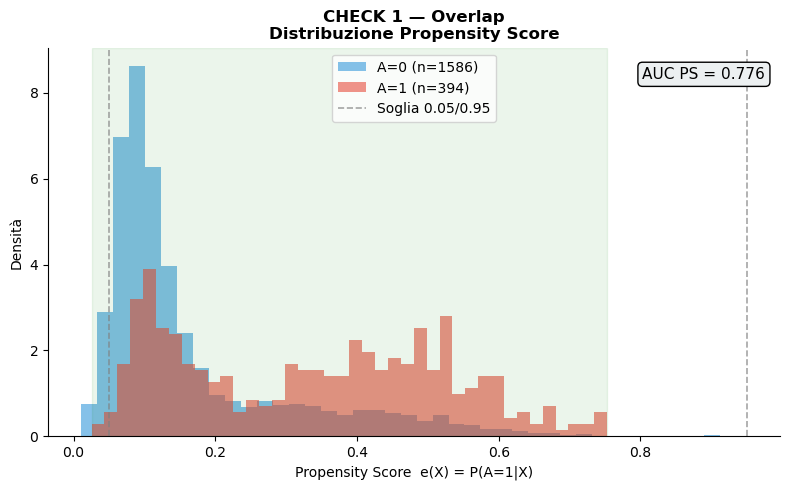

  Salvata: ../output_png/check1_overlap_ps.png


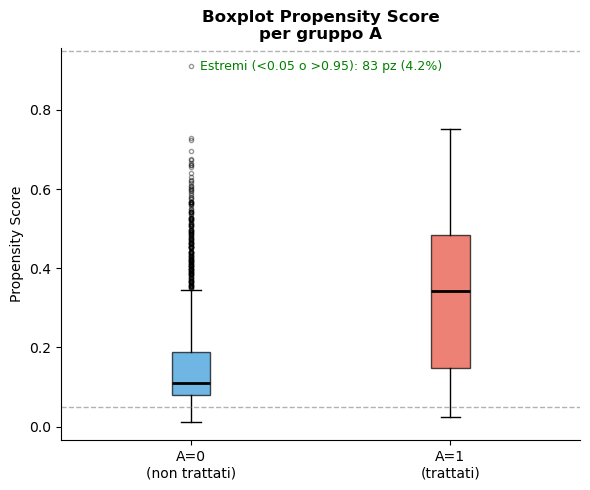

  Salvata: ../output_png/check1_overlap_boxplot.png


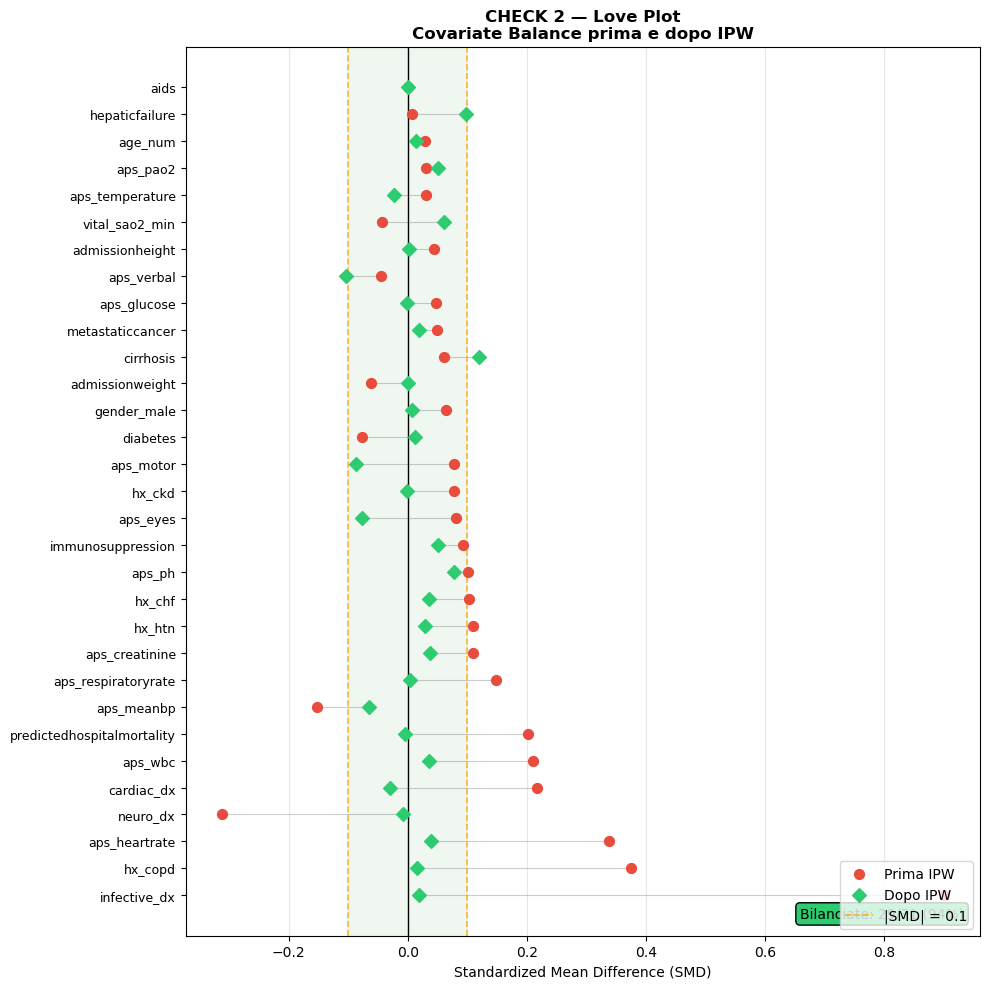

  Salvata: ../output_png/check2_love_plot.png


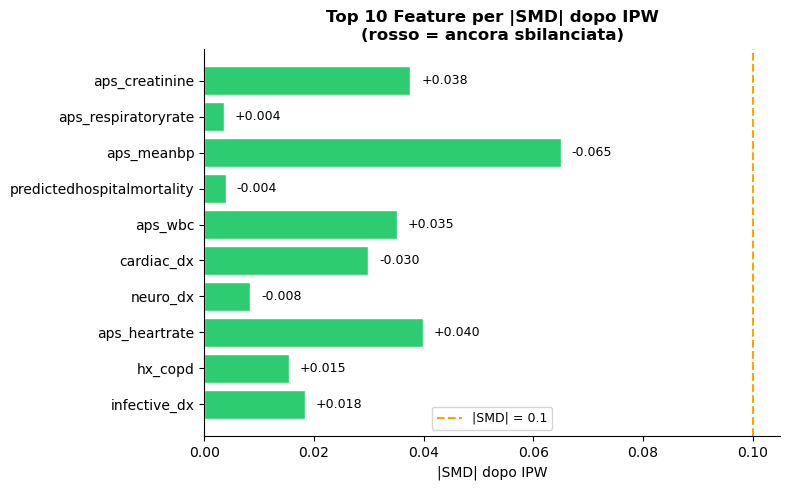

  Salvata: ../output_png/check2_smd_barplot.png

RIEPILOGO CHECK CAUSALI
  Coorte:  1980 pazienti  |  A=1: 394 (19.9%)  |  Y=1: 160 (8.1%)
  CHECK 1 — Overlap:   estremi 83 (4.2%)  →  BUONO
  CHECK 2 — Balance:   bilanciate 29/31 (94%)  →  BUONO
  AUC PS:  0.776  →  BUONO

  Figure salvate in: ../output_png/
    - check1_overlap_ps.png
    - check1_overlap_boxplot.png
    - check2_love_plot.png
    - check2_smd_barplot.png


In [19]:
"""
=============================================================
Check Inferenza Causale — Overlap, Balance, Sensitivity
=============================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings("ignore")

SEED    = 42
DATA_IN = "../data/processed/dataset_XAY.csv"
OUT_DIR = "../output_png/"   # cartella output

np.random.seed(SEED)

# ─────────────────────────────────────────
# 1. CARICA DATASET
# ─────────────────────────────────────────
print("=" * 60)
print("STEP 1 — Carica dataset")
print("=" * 60)

df      = pd.read_csv(DATA_IN)
EXCLUDE = ["patientunitstayid", "Y", "A"]
X_cols  = [c for c in df.columns if c not in EXCLUDE]

A = df["A"].values.astype(float)
Y = df["Y"].values.astype(float)
n = len(A)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[X_cols]).astype(np.float32)

print(f"  Pazienti: {n}  |  A=1: {int(A.sum())} ({A.mean()*100:.1f}%)  |  Y=1: {int(Y.sum())} ({Y.mean()*100:.1f}%)")

# ─────────────────────────────────────────
# 2. PROPENSITY SCORE
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 2 — Stima Propensity Score")
print("=" * 60)

ps_lr  = LogisticRegression(max_iter=1000, C=0.1, random_state=SEED)
ps_lr.fit(X_scaled, A)
e_x    = ps_lr.predict_proba(X_scaled)[:, 1]
e_clip = np.clip(e_x, 0.01, 0.99)
auc    = roc_auc_score(A, e_x)
print(f"  AUC PS: {auc:.3f}")


ps_t0 = e_clip[A == 0]
ps_t1 = e_clip[A == 1]

n_extreme_t1 = np.sum((e_clip > 0.95) & (A == 1))
n_extreme_t0 = np.sum((e_clip < 0.05) & (A == 0))
pct_extreme  = (n_extreme_t1 + n_extreme_t0) / n * 100

# ─────────────────────────────────────────
# 3. SMD
# ─────────────────────────────────────────
w_ipw = np.where(A == 1, 1.0 / e_clip, 1.0 / (1.0 - e_clip))

smd_rows = []
for col in X_cols:
    x = df[col].values.astype(float)
    mean1_raw = x[A == 1].mean()
    mean0_raw = x[A == 0].mean()
    pooled_std = np.sqrt((x[A == 1].var() + x[A == 0].var()) / 2)
    pooled_std = max(pooled_std, 1e-8)
    smd_before = (mean1_raw - mean0_raw) / pooled_std
    mean1_w = np.average(x[A == 1], weights=w_ipw[A == 1])
    mean0_w = np.average(x[A == 0], weights=w_ipw[A == 0])
    smd_after = (mean1_w - mean0_w) / pooled_std
    smd_rows.append({
        "feature":    col,
        "smd_before": smd_before,
        "smd_after":  smd_after,
        "balanced":   abs(smd_after) < 0.1
    })

smd_df  = pd.DataFrame(smd_rows).sort_values("smd_before", key=abs, ascending=False)
pct_bal = smd_df["balanced"].mean() * 100

print(f"  Feature sbilanciate dopo IPW: {(~smd_df['balanced']).sum()} / {len(X_cols)}")

# ═════════════════════════════════════════
# FIGURE SEPARATE
# ═════════════════════════════════════════

# ─────────────────────────────────────────
# FIG 1 — Overlap: distribuzione PS
# ─────────────────────────────────────────
fig1, ax = plt.subplots(figsize=(8, 5))

ax.hist(ps_t0, bins=40, alpha=0.6, color="#3498db",
        label=f"A=0 (n={int((A==0).sum())})", density=True)
ax.hist(ps_t1, bins=40, alpha=0.6, color="#e74c3c",
        label=f"A=1 (n={int((A==1).sum())})", density=True)
ax.axvline(0.05, color="gray", ls="--", lw=1.2, alpha=0.7, label="Soglia 0.05/0.95")
ax.axvline(0.95, color="gray", ls="--", lw=1.2, alpha=0.7)
overlap_min = max(ps_t0.min(), ps_t1.min())
overlap_max = min(ps_t0.max(), ps_t1.max())
ax.axvspan(overlap_min, overlap_max, alpha=0.08, color="green")
ax.text(0.98, 0.92, f"AUC PS = {auc:.3f}",
        transform=ax.transAxes, ha="right", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#ecf0f1"))
ax.set_title("CHECK 1 — Overlap\nDistribuzione Propensity Score", fontweight="bold")
ax.set_xlabel("Propensity Score  e(X) = P(A=1|X)")
ax.set_ylabel("Densità")
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
path1 = OUT_DIR + "check1_overlap_ps.png"
plt.savefig(path1, dpi=150, bbox_inches="tight")
plt.show()
print(f"  Salvata: {path1}")

# ─────────────────────────────────────────
# FIG 2 — Overlap: boxplot PS per gruppo
# ─────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(6, 5))

bp = ax.boxplot([ps_t0, ps_t1],
                labels=["A=0\n(non trattati)", "A=1\n(trattati)"],
                patch_artist=True,
                medianprops=dict(color="black", lw=2),
                flierprops=dict(marker="o", markersize=3, alpha=0.4))
bp["boxes"][0].set_facecolor("#3498db")
bp["boxes"][1].set_facecolor("#e74c3c")
for patch in bp["boxes"]:
    patch.set_alpha(0.7)

ax.axhline(0.05, color="gray", ls="--", lw=1, alpha=0.6)
ax.axhline(0.95, color="gray", ls="--", lw=1, alpha=0.6)
colore = "green" if pct_extreme < 5 else "orange"
ax.text(0.5, 0.97,
        f"Estremi (<0.05 o >0.95): {n_extreme_t1+n_extreme_t0} pz ({pct_extreme:.1f}%)",
        transform=ax.transAxes, ha="center", va="top",
        fontsize=9, color=colore)
ax.set_title("Boxplot Propensity Score\nper gruppo A", fontweight="bold")
ax.set_ylabel("Propensity Score")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
path2 = OUT_DIR + "check1_overlap_boxplot.png"
plt.savefig(path2, dpi=150, bbox_inches="tight")
plt.show()
print(f"  Salvata: {path2}")

# ─────────────────────────────────────────
# FIG 3 — Love Plot (SMD prima e dopo IPW)
# ─────────────────────────────────────────
fig3, ax = plt.subplots(figsize=(10, 10))

y_pos = range(len(smd_df))
ax.scatter(smd_df["smd_before"], y_pos,
           color="#e74c3c", s=50, label="Prima IPW", zorder=3)
ax.scatter(smd_df["smd_after"],  y_pos,
           color="#2ecc71", s=50, marker="D", label="Dopo IPW", zorder=3)

for i, (_, row) in enumerate(smd_df.iterrows()):
    ax.plot([row["smd_before"], row["smd_after"]], [i, i],
            color="gray", alpha=0.4, lw=0.8)

ax.axvline(0,    color="black",  lw=1.0)
ax.axvline( 0.1, color="orange", lw=1.2, ls="--", alpha=0.8, label="|SMD| = 0.1")
ax.axvline(-0.1, color="orange", lw=1.2, ls="--", alpha=0.8)
ax.axvspan(-0.1, 0.1, alpha=0.06, color="green")

ax.set_yticks(list(y_pos))
ax.set_yticklabels(smd_df["feature"], fontsize=9)
ax.set_xlabel("Standardized Mean Difference (SMD)")
ax.set_title("CHECK 2 — Love Plot\nCovariate Balance prima e dopo IPW",
             fontweight="bold")
ax.legend(fontsize=10, loc="lower right")
ax.grid(axis="x", alpha=0.3)

ax.text(0.98, 0.02,
        f"Bilanciate: {smd_df['balanced'].sum()}/{len(smd_df)} ({pct_bal:.0f}%)",
        transform=ax.transAxes, ha="right", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="#2ecc71" if pct_bal > 80 else "#f39c12"))

plt.tight_layout()
path3 = OUT_DIR + "check2_love_plot.png"
plt.savefig(path3, dpi=150, bbox_inches="tight")
plt.show()
print(f"  Salvata: {path3}")

# ─────────────────────────────────────────
# FIG 4 — Top 10 SMD dopo IPW (barplot)
# ─────────────────────────────────────────
fig4, ax = plt.subplots(figsize=(8, 5))

top_n   = 10
top_smd = smd_df.head(top_n)
colors_bar = ["#e74c3c" if abs(v) > 0.1 else "#2ecc71"
              for v in top_smd["smd_after"]]
bars = ax.barh(top_smd["feature"], top_smd["smd_after"].abs(),
               color=colors_bar, edgecolor="white")
ax.axvline(0.1, color="orange", ls="--", lw=1.5, label="|SMD| = 0.1")
ax.set_title(f"Top {top_n} Feature per |SMD| dopo IPW\n(rosso = ancora sbilanciata)",
             fontweight="bold")
ax.set_xlabel("|SMD| dopo IPW")
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, val in zip(bars, top_smd["smd_after"]):
    ax.text(bar.get_width() + 0.002,
            bar.get_y() + bar.get_height() / 2,
            f"{val:+.3f}", va="center", fontsize=9)

plt.tight_layout()
path4 = OUT_DIR + "check2_smd_barplot.png"
plt.savefig(path4, dpi=150, bbox_inches="tight")
plt.show()
print(f"  Salvata: {path4}")

# ─────────────────────────────────────────
# RIEPILOGO FINALE
# ─────────────────────────────────────────
overlap_ok = "BUONO"   if pct_extreme < 5  else ("MODERATO" if pct_extreme < 15 else "SCARSO")
balance_ok = "BUONO"   if pct_bal > 80     else ("PARZIALE"  if pct_bal > 60  else "SCARSO")
auc_ok     = "BUONO"   if 0.65 < auc < 0.9 else "ATTENZIONE"

print("\n" + "=" * 60)
print("RIEPILOGO CHECK CAUSALI")
print("=" * 60)
print(f"  Coorte:  {n} pazienti  |  A=1: {int(A.sum())} ({A.mean()*100:.1f}%)  |  Y=1: {int(Y.sum())} ({Y.mean()*100:.1f}%)")
print(f"  CHECK 1 — Overlap:   estremi {n_extreme_t1+n_extreme_t0} ({pct_extreme:.1f}%)  →  {overlap_ok}")
print(f"  CHECK 2 — Balance:   bilanciate {smd_df['balanced'].sum()}/{len(smd_df)} ({pct_bal:.0f}%)  →  {balance_ok}")
print(f"  AUC PS:  {auc:.3f}  →  {auc_ok}")
print(f"\n  Figure salvate in: {OUT_DIR}")
print("    - check1_overlap_ps.png")
print("    - check1_overlap_boxplot.png")
print("    - check2_love_plot.png")
print("    - check2_smd_barplot.png")


CHECK 3 — Stabilità dei pesi IPW
  Media:    0.9953
  Mediana:  0.8956
  Std:      0.4740
  P95:      1.7779
  P99:      2.5996
  Max:      9.1075
  Pesi > P99: 20 pazienti (1.0%)


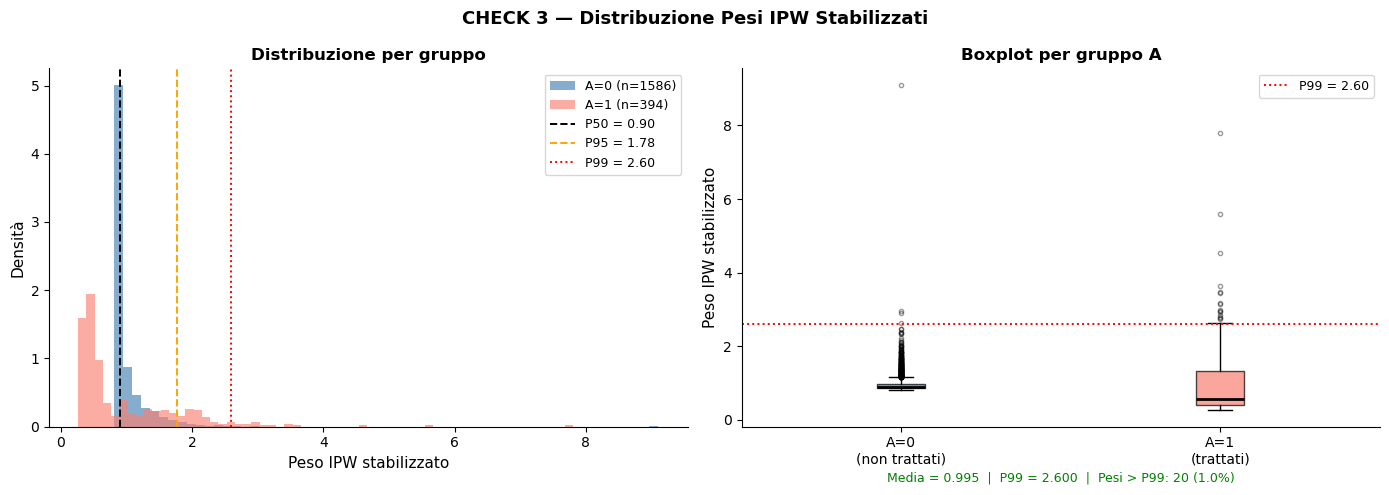

In [22]:
# ─────────────────────────────────────────
# CHECK 3 — STABILITÀ DEI PESI IPW
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("CHECK 3 — Stabilità dei pesi IPW")
print("=" * 60)

p_A1   = A.mean()
w_iptw = np.where(A == 1,
                  p_A1 / e_clip,
                  (1 - p_A1) / (1 - e_clip))

# Statistiche descrittive
print(f"  Media:    {w_iptw.mean():.4f}")
print(f"  Mediana:  {np.median(w_iptw):.4f}")
print(f"  Std:      {w_iptw.std():.4f}")
print(f"  P95:      {np.percentile(w_iptw, 95):.4f}")
print(f"  P99:      {np.percentile(w_iptw, 99):.4f}")
print(f"  Max:      {w_iptw.max():.4f}")

n_extreme = np.sum(w_iptw > np.percentile(w_iptw, 99))
print(f"  Pesi > P99: {n_extreme} pazienti ({n_extreme/len(w_iptw)*100:.1f}%)")

# ── FIGURA ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("CHECK 3 — Distribuzione Pesi IPW Stabilizzati",
             fontsize=13, fontweight="bold")

# ── Sinistra: istogramma generale ────────
ax = axes[0]
ax.hist(w_iptw[A == 0], bins=60, alpha=0.65,
        color="steelblue", label=f"A=0 (n={int((A==0).sum())})", density=True)
ax.hist(w_iptw[A == 1], bins=60, alpha=0.65,
        color="salmon",   label=f"A=1 (n={int((A==1).sum())})", density=True)

for pct, col, ls in [(50, "black", "--"), (95, "orange", "--"), (99, "red", ":")]:
    val = np.percentile(w_iptw, pct)
    ax.axvline(val, color=col, linestyle=ls, linewidth=1.4,
               label=f"P{pct} = {val:.2f}")

ax.set_xlabel("Peso IPW stabilizzato", fontsize=11)
ax.set_ylabel("Densità", fontsize=11)
ax.set_title("Distribuzione per gruppo", fontweight="bold")
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── Destra: boxplot per gruppo ────────────
ax2 = axes[1]
bp = ax2.boxplot(
    [w_iptw[A == 0], w_iptw[A == 1]],
    labels=["A=0\n(non trattati)", "A=1\n(trattati)"],
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    flierprops=dict(marker="o", markersize=3, alpha=0.4)
)
bp["boxes"][0].set_facecolor("steelblue")
bp["boxes"][0].set_alpha(0.7)
bp["boxes"][1].set_facecolor("salmon")
bp["boxes"][1].set_alpha(0.7)

p99_val = np.percentile(w_iptw, 99)
ax2.axhline(p99_val, color="red", linestyle=":", linewidth=1.4,
            label=f"P99 = {p99_val:.2f}")

media = w_iptw.mean()
n_out = np.sum(w_iptw > p99_val)
colore = "green" if n_out / len(w_iptw) < 0.02 else "red"

# ── annotazione sotto l'asse X, fuori dal grafico ──
ax2.set_xlabel(
    f"Media = {media:.3f}  |  P99 = {p99_val:.3f}  |  "
    f"Pesi > P99: {n_out} ({n_out/len(w_iptw)*100:.1f}%)",
    fontsize=9, color=colore
)

ax2.set_ylabel("Peso IPW stabilizzato", fontsize=11)
ax2.set_title("Boxplot per gruppo A", fontweight="bold")
ax2.legend(fontsize=9, loc="upper right")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_PNG.replace("causal_checks", "ipw_weights"),
            dpi=150, bbox_inches="tight")
plt.show()

CLASSIFICAZIONE COVARIATE
  Soglia SMD:    |SMD| >= 0.1  (Austin 2009)
  Soglia cor(Y): |r|   >= 0.05
role
Irrilevante             11
Confondente (A+Y)        9
Solo outcome (Y)         7
Solo trattamento (A)     4

Top confondenti (|SMD| + |cor_Y|):
                                 SMD     cor_Y     score
infective_dx                0.899831  0.167838  1.067669
predictedhospitalmortality  0.202430  0.268397  0.470827
aps_heartrate               0.337291  0.109695  0.446986
aps_wbc                     0.209409  0.074551  0.283960
cardiac_dx                  0.216245  0.059255  0.275500
aps_ph                      0.101677  0.169526  0.271202
aps_respiratoryrate         0.147698  0.115810  0.263508
hx_chf                      0.102699  0.101293  0.203992
aps_creatinine              0.109867  0.053898  0.163765


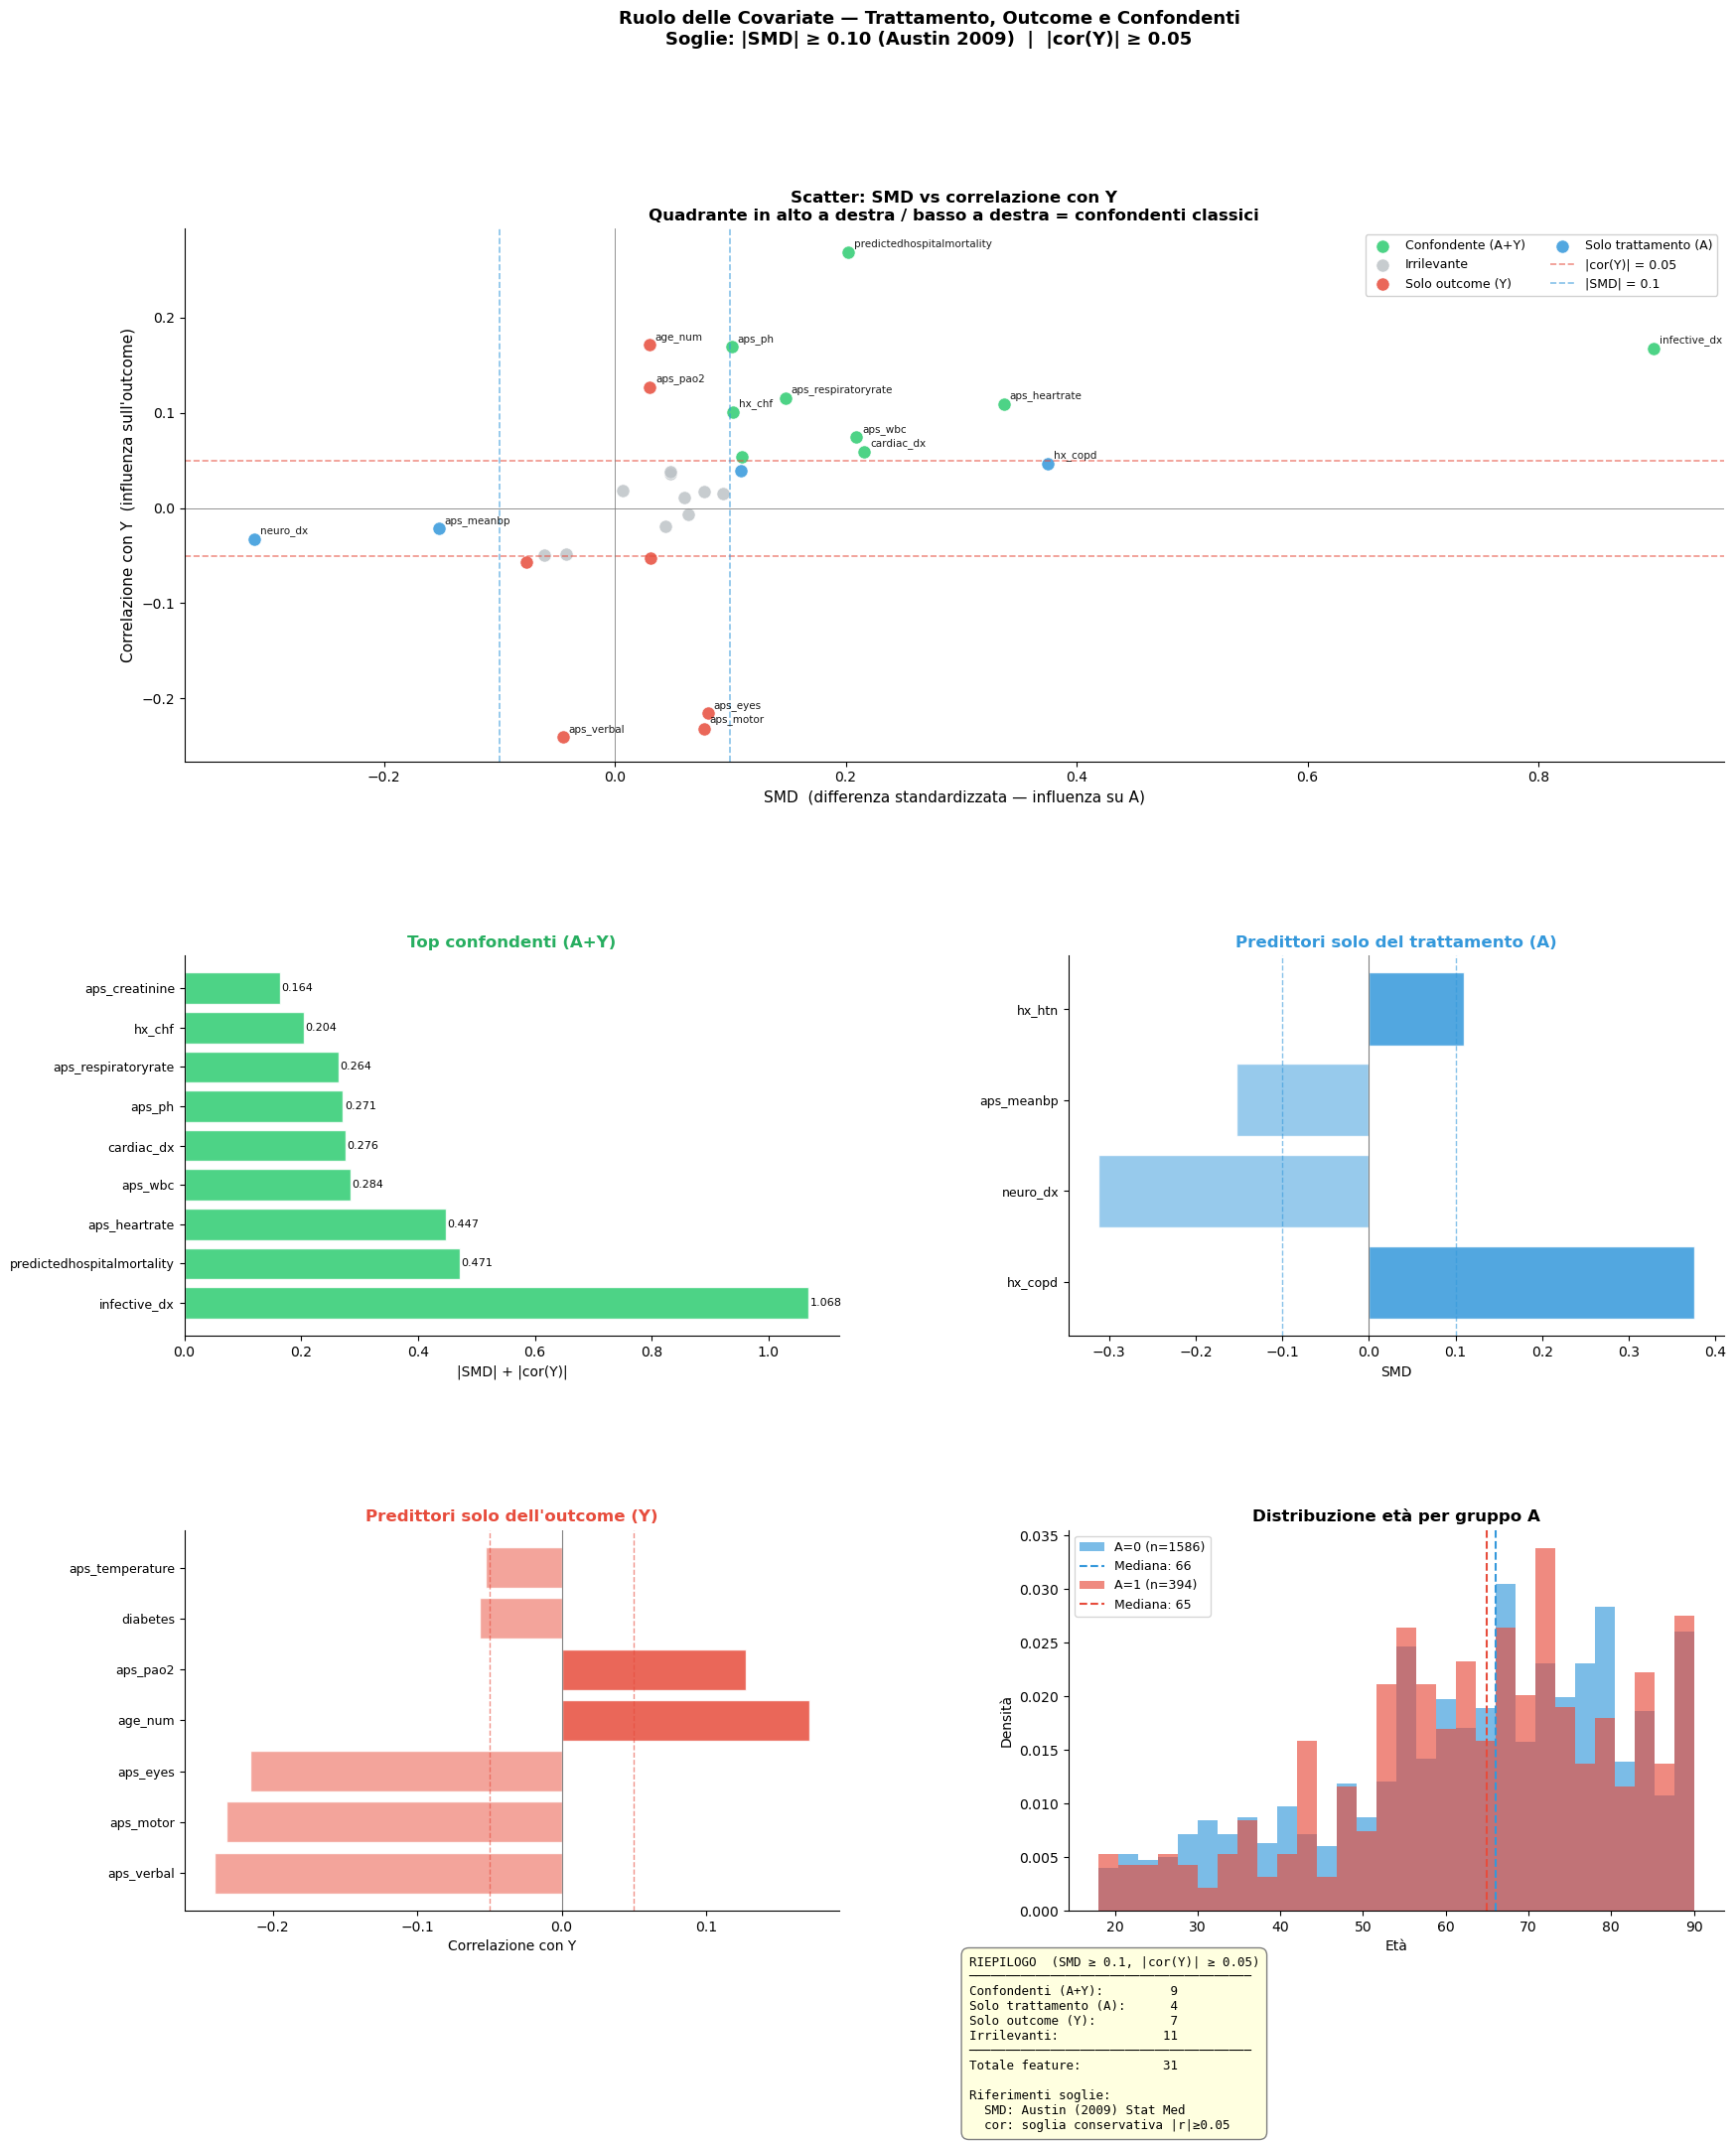


Figura salvata in ../output_png/covariate_roles.png


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings("ignore")

DATA_IN = "../data/processed/dataset_XAY.csv"
OUT_PNG = "../output_png/covariate_roles.png"

df      = pd.read_csv(DATA_IN)
EXCLUDE = ["patientunitstayid", "Y", "A"]
X_cols  = [c for c in df.columns if c not in EXCLUDE]

A = df["A"].values.astype(float)
Y = df["Y"].values.astype(float)
X = df[X_cols]

# ─────────────────────────────────────────
# 1. SMD per ogni covariata (influenza su A)
# ─────────────────────────────────────────
# |SMD| > 0.1 è la soglia standard della letteratura
# Austin (2009), Cohen (1988)

def compute_smd(x, a):
    x1 = x[a == 1]
    x0 = x[a == 0]
    mean_diff = x1.mean() - x0.mean()
    pooled_std = np.sqrt((x1.std()**2 + x0.std()**2) / 2)
    if pooled_std == 0:
        return 0.0
    return mean_diff / pooled_std

smd = pd.Series(
    {col: compute_smd(X[col].values, A) for col in X_cols},
    name="SMD"
)

# ─────────────────────────────────────────
# 2. CORRELAZIONE CON Y (influenza su outcome)
# ─────────────────────────────────────────
# Correlazione punto-biseriale (Pearson tra continua e binaria)
# |r| > 0.05 come soglia minima — conservativa ma motivata

cor_Y = pd.Series(
    {col: np.corrcoef(X[col].values, Y)[0, 1] for col in X_cols},
    name="cor_Y"
)

# ─────────────────────────────────────────
# 3. CLASSIFICAZIONE RUOLI
# ─────────────────────────────────────────
SMD_THR = 0.10   # soglia standard letteratura (Austin 2009)
COR_THR = 0.05   # soglia correlazione con Y

results = pd.DataFrame({
    "SMD":        smd,
    "abs_SMD":    smd.abs(),
    "cor_Y":      cor_Y,
    "abs_cor_Y":  cor_Y.abs(),
})

pred_A = results["abs_SMD"]   >= SMD_THR
pred_Y = results["abs_cor_Y"] >= COR_THR

results["role"] = "Irrilevante"
results.loc[ pred_A & ~pred_Y, "role"] = "Solo trattamento (A)"
results.loc[~pred_A &  pred_Y, "role"] = "Solo outcome (Y)"
results.loc[ pred_A &  pred_Y, "role"] = "Confondente (A+Y)"

COLORS = {
    "Solo trattamento (A)": "#3498db",
    "Solo outcome (Y)":     "#e74c3c",
    "Confondente (A+Y)":    "#2ecc71",
    "Irrilevante":          "#bdc3c7",
}

print("=" * 50)
print("CLASSIFICAZIONE COVARIATE")
print(f"  Soglia SMD:    |SMD| >= {SMD_THR}  (Austin 2009)")
print(f"  Soglia cor(Y): |r|   >= {COR_THR}")
print("=" * 50)
print(results["role"].value_counts().to_string())
print("\nTop confondenti (|SMD| + |cor_Y|):")
conf = results[results["role"] == "Confondente (A+Y)"].copy()
conf["score"] = conf["abs_SMD"] + conf["abs_cor_Y"]
print(conf.sort_values("score", ascending=False)
         [["SMD", "cor_Y", "score"]].head(10).to_string())

# ─────────────────────────────────────────
# 4. FIGURA
# ─────────────────────────────────────────
fig = plt.figure(figsize=(20, 22))
fig.suptitle(
    "Ruolo delle Covariate — Trattamento, Outcome e Confondenti\n"
    "Soglie: |SMD| ≥ 0.10 (Austin 2009)  |  |cor(Y)| ≥ 0.05",
    fontsize=13, fontweight="bold", y=0.98
)

gs = gridspec.GridSpec(3, 2, figure=fig,
                       hspace=0.45, wspace=0.35,
                       height_ratios=[1.4, 1, 1])

# ── PANEL 1: Scatter SMD vs cor_Y ────────────────────────────
ax1 = fig.add_subplot(gs[0, :])

for role, grp in results.groupby("role"):
    ax1.scatter(grp["SMD"], grp["cor_Y"],
                color=COLORS[role], label=role,
                s=90, alpha=0.85, edgecolors="white", linewidths=0.5)
    for feat, row in grp.iterrows():
        if row["abs_SMD"] > SMD_THR * 1.3 or row["abs_cor_Y"] > COR_THR * 1.5:
            ax1.annotate(feat,
                         (row["SMD"], row["cor_Y"]),
                         fontsize=7.5, alpha=0.9,
                         xytext=(4, 4), textcoords="offset points")

# Soglie come linee tratteggiate
ax1.axhline( COR_THR, color="#e74c3c", linewidth=1.2,
             linestyle="--", alpha=0.6, label=f"|cor(Y)| = {COR_THR}")
ax1.axhline(-COR_THR, color="#e74c3c", linewidth=1.2,
             linestyle="--", alpha=0.6)
ax1.axvline( SMD_THR, color="#3498db", linewidth=1.2,
             linestyle="--", alpha=0.6, label=f"|SMD| = {SMD_THR}")
ax1.axvline(-SMD_THR, color="#3498db", linewidth=1.2,
             linestyle="--", alpha=0.6)
ax1.axhline(0, color="gray", linewidth=0.6)
ax1.axvline(0, color="gray", linewidth=0.6)

ax1.set_xlabel("SMD  (differenza standardizzata — influenza su A)", fontsize=11)
ax1.set_ylabel("Correlazione con Y  (influenza sull'outcome)", fontsize=11)
ax1.set_title(
    "Scatter: SMD vs correlazione con Y\n"
    "Quadrante in alto a destra / basso a destra = confondenti classici",
    fontweight="bold"
)
ax1.legend(fontsize=9, framealpha=0.9, ncol=2)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# ── PANEL 2: Top confondenti ──────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])

conf_top = conf.nlargest(12, "score")
y_pos = range(len(conf_top))
bars2 = ax2.barh(list(y_pos), conf_top["score"],
                 color="#2ecc71", alpha=0.85, edgecolor="white")
ax2.set_yticks(list(y_pos))
ax2.set_yticklabels(conf_top.index, fontsize=9)
ax2.set_xlabel("|SMD| + |cor(Y)|", fontsize=10)
ax2.set_title("Top confondenti (A+Y)", fontweight="bold", color="#27ae60")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
for bar, val in zip(bars2, conf_top["score"]):
    ax2.text(bar.get_width() + 0.003,
             bar.get_y() + bar.get_height() / 2,
             f"{val:.3f}", va="center", fontsize=8)

# ── PANEL 3: Top predittori solo di A ────────────────────────
ax3 = fig.add_subplot(gs[1, 1])

pred_a_only = results[results["role"] == "Solo trattamento (A)"] \
              .nlargest(10, "abs_SMD")
y_pos3 = range(len(pred_a_only))
cols3  = ["#3498db" if v > 0 else "#85c1e9" for v in pred_a_only["SMD"]]
ax3.barh(list(y_pos3), pred_a_only["SMD"],
         color=cols3, alpha=0.85, edgecolor="white")
ax3.set_yticks(list(y_pos3))
ax3.set_yticklabels(pred_a_only.index, fontsize=9)
ax3.axvline(0, color="gray", linewidth=0.8)
ax3.axvline( SMD_THR, color="#3498db", linestyle="--",
             linewidth=1.0, alpha=0.6)
ax3.axvline(-SMD_THR, color="#3498db", linestyle="--",
             linewidth=1.0, alpha=0.6)
ax3.set_xlabel("SMD", fontsize=10)
ax3.set_title("Predittori solo del trattamento (A)",
              fontweight="bold", color="#3498db")
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)

# ── PANEL 4: Top predittori solo di Y ────────────────────────
ax4 = fig.add_subplot(gs[2, 0])

pred_y_only = results[results["role"] == "Solo outcome (Y)"] \
              .nlargest(10, "abs_cor_Y")
y_pos4 = range(len(pred_y_only))
cols4  = ["#e74c3c" if v > 0 else "#f1948a" for v in pred_y_only["cor_Y"]]
ax4.barh(list(y_pos4), pred_y_only["cor_Y"],
         color=cols4, alpha=0.85, edgecolor="white")
ax4.set_yticks(list(y_pos4))
ax4.set_yticklabels(pred_y_only.index, fontsize=9)
ax4.axvline(0, color="gray", linewidth=0.8)
ax4.axvline( COR_THR, color="#e74c3c", linestyle="--",
             linewidth=1.0, alpha=0.6)
ax4.axvline(-COR_THR, color="#e74c3c", linestyle="--",
             linewidth=1.0, alpha=0.6)
ax4.set_xlabel("Correlazione con Y", fontsize=10)
ax4.set_title("Predittori solo dell'outcome (Y)",
              fontweight="bold", color="#e74c3c")
ax4.spines["top"].set_visible(False)
ax4.spines["right"].set_visible(False)

# ── PANEL 5: Distribuzione età per gruppo ────────────────────
ax5 = fig.add_subplot(gs[2, 1])

age_col = next((c for c in ["age_num", "age"] if c in df.columns), None)
if age_col:
    age = pd.to_numeric(df[age_col], errors="coerce")
    for a_val, color, label in [
        (0, "#3498db", f"A=0 (n={int((A==0).sum())})"),
        (1, "#e74c3c", f"A=1 (n={int((A==1).sum())})")
    ]:
        ax5.hist(age[A == a_val], bins=30, alpha=0.65,
                 color=color, density=True, label=label)
        med = age[A == a_val].median()
        ax5.axvline(med, color=color, linestyle="--",
                    linewidth=1.5, label=f"Mediana: {med:.0f}")
    ax5.set_xlabel("Età", fontsize=10)
    ax5.set_ylabel("Densità", fontsize=10)
    ax5.set_title("Distribuzione età per gruppo A", fontweight="bold")
    ax5.legend(fontsize=9)
    ax5.spines["top"].set_visible(False)
    ax5.spines["right"].set_visible(False)

# ── Riepilogo testuale ────────────────────────────────────────
counts  = results["role"].value_counts()
summary = (
    f"RIEPILOGO  (SMD ≥ {SMD_THR}, |cor(Y)| ≥ {COR_THR})\n"
    f"{'─'*38}\n"
    f"Confondenti (A+Y):       {counts.get('Confondente (A+Y)', 0):>3}\n"
    f"Solo trattamento (A):    {counts.get('Solo trattamento (A)', 0):>3}\n"
    f"Solo outcome (Y):        {counts.get('Solo outcome (Y)', 0):>3}\n"
    f"Irrilevanti:             {counts.get('Irrilevante', 0):>3}\n"
    f"{'─'*38}\n"
    f"Totale feature:          {len(results):>3}\n\n"
    f"Riferimenti soglie:\n"
    f"  SMD: Austin (2009) Stat Med\n"
    f"  cor: soglia conservativa |r|≥0.05"
)
fig.text(0.52, 0.01, summary, fontsize=9,
         fontfamily="monospace",
         bbox=dict(boxstyle="round,pad=0.6",
                   facecolor="lightyellow", edgecolor="gray"))

plt.savefig(OUT_PNG, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nFigura salvata in {OUT_PNG}")